In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

1) URL: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard

2) Column Name and descriptions

- Date: 	Date of the booking
- Time: 	Time of the booking
- Booking ID: 	Unique identifier for each ride booking
- Booking Status: 	Status of booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.)
- Customer ID: 	Unique identifier for customers
- Vehicle Type: 	Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)
- Pickup Location: 	Starting location of the ride
- Drop Location: 	Destination location of the ride
- Avg VTAT: 	Average time for driver to reach pickup location (in minutes)
- Avg CTAT: 	Average trip duration from pickup to destination (in minutes)
- Cancelled Rides by Customer: 	Customer-initiated cancellation flag
- Reason for cancelling by Customer: 	Reason for customer cancellation
- Cancelled Rides by Driver: 	Driver-initiated cancellation flag
- Driver Cancellation Reason: 	Reason for driver cancellation
- Incomplete Rides: 	Incomplete ride flag
- Incomplete Rides Reason: 	Reason for incomplete rides
- Booking Value: 	Total fare amount for the ride
- Ride Distance: 	Distance covered during the ride (in km)
- Driver Ratings: 	Rating given to driver (1-5 scale)
- Customer Rating: 	Rating given by customer (1-5 scale)
- Payment Method: 	Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)

3) Goal: Predicting uber ride cancellations

#### Data Types, Summary Stats, Null Values and Duplicated Values

In [123]:
data_path = "/home/anderson/Documents/uber_dataset/data/ncr_ride_bookings.csv"
df = pd.read_csv(data_path)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [124]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [126]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [127]:
df.duplicated().sum()

np.int64(0)

#### Timestamp Processing

In [128]:
# Convert Date and Time to datetime
df['Date'] = pd.to_datetime(df['Date'], errors="coerce")
df['Time'] = pd.to_datetime(df['Time'], format="%H:%M:%S", errors="coerce").dt.time

# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'].astype('str') + ' ' + df['Time'].astype('str'), errors="coerce")

# Extract temporal features
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.dayofweek # Monday = 0, Sunday = 6
df['is_weekend'] = df['weekday'].isin([5, 6])

In [129]:
df[['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend']].head()

,datetime,hour,day,month,weekday,is_weekend
0,2024-03-23 12:29:38,12,23,3,5,True
1,2024-11-29 18:01:39,18,29,11,4,False
2,2024-08-23 08:56:10,8,23,8,4,False
3,2024-10-21 17:17:25,17,21,10,0,False
4,2024-09-16 22:08:00,22,16,9,0,False


#### Missing Values Strategy

In [130]:
# Create binary flags from cancellation/incomplete columns
df['is_cancelled_customer'] = df['Cancelled Rides by Customer'].notnull()
df['is_cancelled_driver'] = df['Cancelled Rides by Driver'].notnull()
df['is_incomplete'] = df['Incomplete Rides'].notnull()

# Create a flag for missing ratings and booking values
df['missing_driver_rating'] = df['Driver Ratings'].isnull()
df['missing_customer_rating'] = df['Customer Rating'].isnull()
df['missing_booking_value'] = df['Booking Value'].isnull()
df['missing_payment_method'] = df['Payment Method'].isnull()

# Optional: Fill CTAT and VTAT with median if needed
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())

# Optional: Fill Ratings and Booking Value with zeros if needed (for modeling)
# df['Driver Ratings'].fillna(0, inplace=True)
# df['Customer Rating'].fillna(0, inplace=True)
# df['Booking Value'].fillna(0, inplace=True)

# Check new flags
df[['is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
    'missing_driver_rating', 'missing_customer_rating',
    'missing_booking_value', 'missing_payment_method']].sum()

is_cancelled_customer      10500
is_cancelled_driver        27000
is_incomplete               9000
missing_driver_rating      57000
missing_customer_rating    57000
missing_booking_value      48000
missing_payment_method     48000
dtype: int64

#### Define Target for Customer Cancellation

In [131]:
# Target variable
df['target_customer_cancelled'] = df['is_cancelled_customer'].astype(int)

# Quick target distribution check
df['target_customer_cancelled'].value_counts(normalize=True)

target_customer_cancelled
0    0.93
1    0.07
Name: proportion, dtype: float64

#### EDA for Customer Cancellations

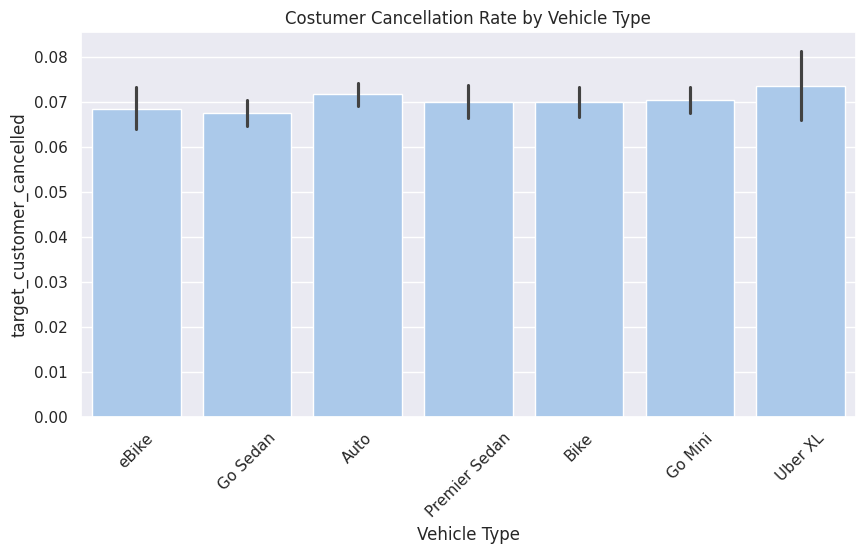

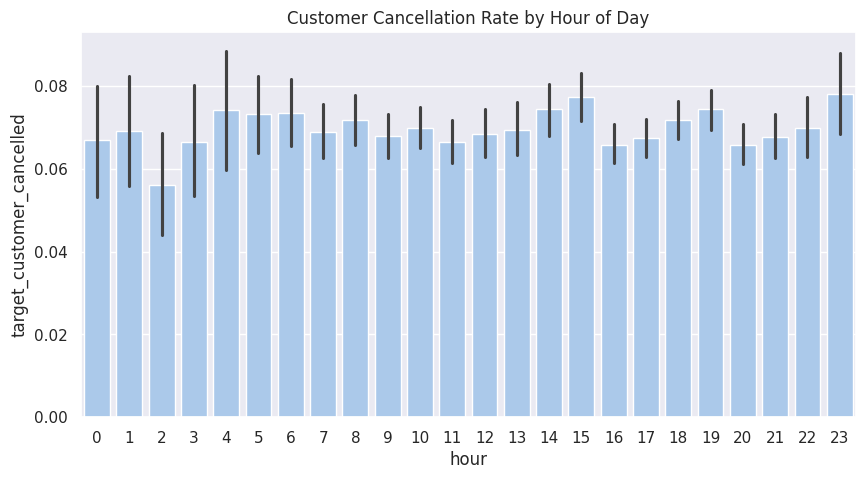

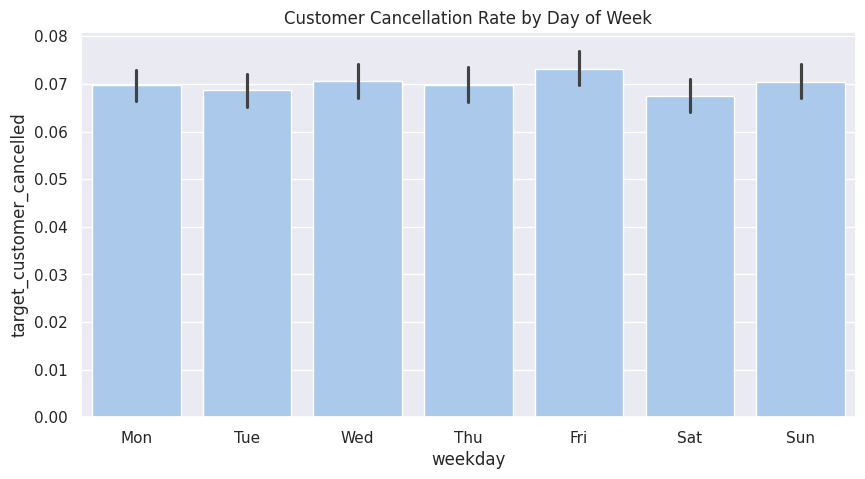

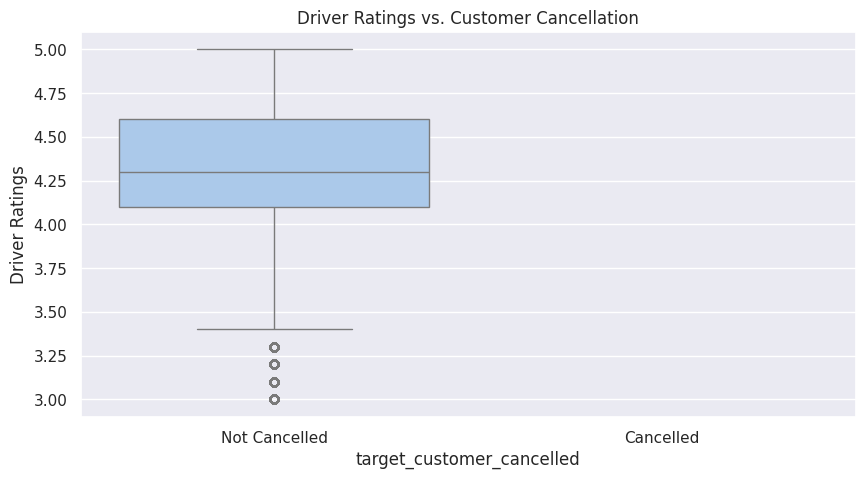

In [132]:
sns.set_style('whitegrid')
sns.set_theme(palette='pastel')

# 1. Cancellation Rate by Vehicle Type
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Vehicle Type", y="target_customer_cancelled")
plt.title("Costumer Cancellation Rate by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

# 2. Correlation Rate by Hour
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="hour", y="target_customer_cancelled")
plt.title("Customer Cancellation Rate by Hour of Day")
plt.show()

# 3. Cancellation Rate by day of week
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="weekday", y="target_customer_cancelled")
plt.title("Customer Cancellation Rate by Day of Week")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

# 4. Driver rating vs Cancellation
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="target_customer_cancelled", y="Driver Ratings")
plt.title("Driver Ratings vs. Customer Cancellation")
plt.xticks([0, 1], labels=['Not Cancelled', 'Cancelled'])
plt.show()

#### Location + Time EDA

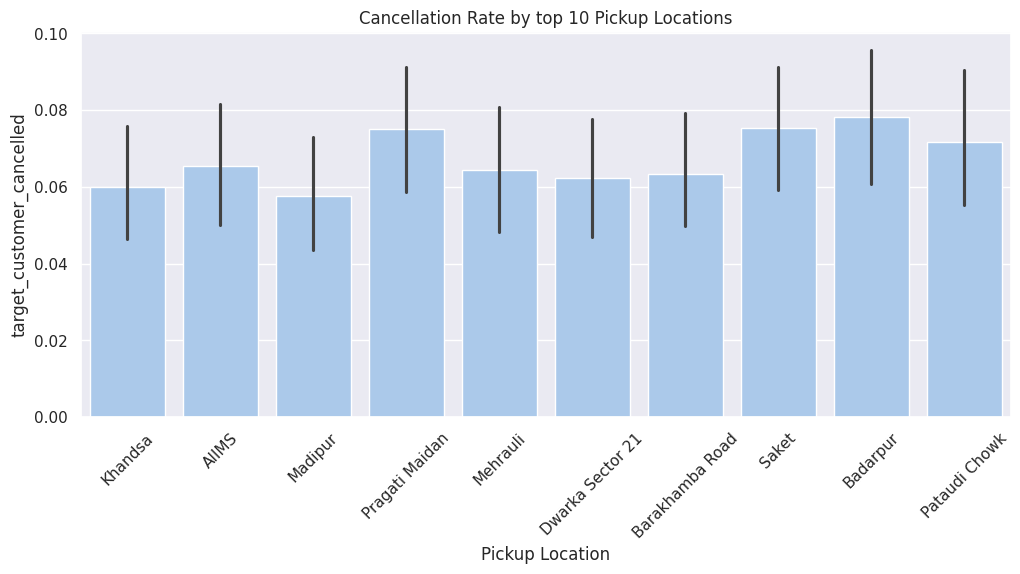

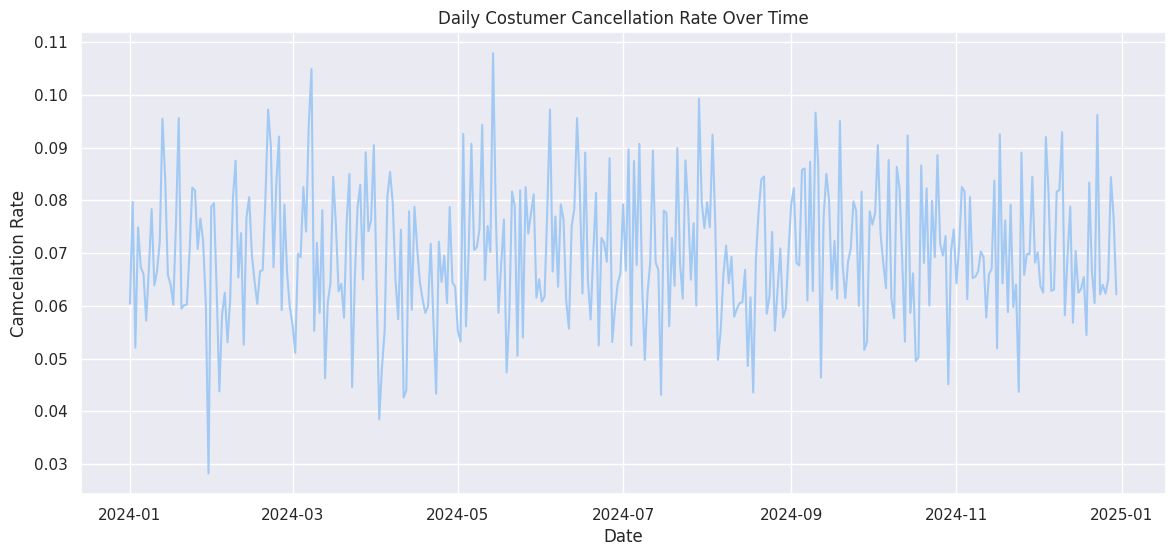

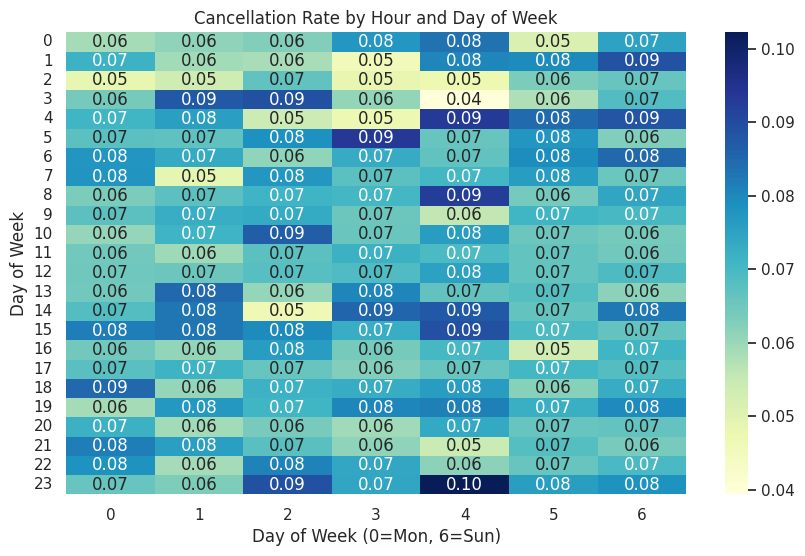

In [133]:
# 1. Top 10 Pickup Locations by Count

top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df_top_pickups = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top_pickups, x="Pickup Location", y="target_customer_cancelled")
plt.title("Cancellation Rate by top 10 Pickup Locations")
plt.xticks(rotation=45)
plt.show()

# 2. Trend of Cancellations Over Time (Daily)
df_daily = df.groupby('Date')['target_customer_cancelled'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_daily, x="Date", y="target_customer_cancelled")
plt.title("Daily Costumer Cancellation Rate Over Time")
plt.ylabel("Camcelation Rate")
plt.xlabel("Date")
plt.show()

# 3. Heatmap of Hour vs Day of Week

heatmap_data = df.pivot_table(
    index="hour",
    columns="weekday",
    values="target_customer_cancelled",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(data=heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Cancellation Rate by Hour and Day of Week")
plt.ylabel("Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

#### Feature Engineering

In [134]:
# 1. Vehicle Type One-Hot Encoding
df = pd.get_dummies(df, columns=['Vehicle Type'], prefix='vehicle', drop_first=True)

# 2. Encode Top 10 Pickup Locations
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df['pickup_encoded'] = df['Pickup Location'].apply(lambda x: x if x in top_pickups else 'Other')
df = pd.get_dummies(df, columns=['pickup_encoded'], prefix='pickup', drop_first=True)

# 3. Encode Top 10 Drop Locations
top_drops = df['Drop Location'].value_counts().nlargest(10).index
df['drop_encoded'] = df['Drop Location'].apply(lambda x: x if x in top_drops else 'Other')
df = pd.get_dummies(df, columns=['drop_encoded'], prefix='drop', drop_first=True)

# 4. Customer Booking Frequency
cust_counts = df['Customer ID'].value_counts().to_dict()
df['customer_total_bookings'] = df['Customer ID'].map(cust_counts)

# 5. Replace NaNs in numeric columns with placeholder or leave as-is
num_cols = ['Avg VTAT', 'Avg CTAT', 'Driver Ratings', 'Customer Rating']

# 6. Drop columns not needed for modeling
drop_cols = [
    'Booking ID', 'Customer ID', 'Pickup Location', 'Drop Location',
    'Cancelled Rides by Customer', 'Reason for cancelling by Customer',
    'Cancelled Rides by Driver', 'Driver Cancellation Reason',
    'Incomplete Rides', 'Incomplete Rides Reason', 'Date', 'Time', 'datetime'
]
df.drop(columns=drop_cols, inplace=True)

# 7. Final feature list
features = [col for col in df.columns if col != 'target_customer_cancelled']
target = 'target_customer_cancelled'

print(f"Total Features for Modeling: {len(features)}")

Total Features for Modeling: 47


#### Apply Class Weights

We'll compute balanced class weights based on the distribution of target_customer_cancelled, and use those in the model training phase

In [135]:
# Compute class weights using sklearn

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['target_customer_cancelled']
)

weights = dict(enumerate(class_weights))
print("Class Weights:", weights)

Class Weights: {0: np.float64(0.5376344086021505), 1: np.float64(7.142857142857143)}


In [137]:
# Combine X and y temporarily
temp_df = df.copy()
temp_df['target'] = df[target]

# Select only numeric columns
numeric_cols = temp_df.select_dtypes(include=[np.number]).columns

# Compute correlation with target
correlations = temp_df[numeric_cols].corr()['target'].sort_values(key=abs, ascending=False)

# Display top correlations (excluding target itself)
print(f"Top Correlated Features with Target:\n{correlations.drop('target')}")

Top Correlated Features with Target:
target_customer_cancelled    1.000000
Avg VTAT                     0.306592
Avg CTAT                    -0.008883
month                        0.001480
hour                         0.001475
customer_total_bookings      0.001330
day                         -0.000854
weekday                      0.000595
Booking Value                     NaN
Ride Distance                     NaN
Driver Ratings                    NaN
Customer Rating                   NaN
Name: target, dtype: float64


#### Logistic Regression with Class Weights

In [ ]:
# Drop target and keep only numeric features
clean_features = df.select_dtypes(include=['number']).columns.drop('target_customer_cancelled')

# Setup X and y
X = df[clean_features]
y = df['target_customer_cancelled']

# Apply pipeline for imputer missing values and training model
pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_regression", LogisticRegression(class_weight="balanced", max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Logistic Regression
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob)}")
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))

ROC AUC Score: 0.7797575439494794
Classification Report:
               precision    recall  f1-score   support

           0      0.965     0.727     0.829     27900
           1      0.153     0.654     0.248      2100

    accuracy                          0.722     30000
   macro avg      0.559     0.691     0.539     30000
weighted avg      0.909     0.722     0.789     30000



/home/anderson/Documents/uber_dataset/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Random Forest with Class Weights

In [149]:
# Define cleaned features
leaky_features = [
    'Avg VTAT', 'Ride Distance',
    'Booking Value', 'Customer Rating', 'Driver Ratings',
    'Booking Status', 'Payment Method',
    'missing_booking_value', 'missing_payment_method',
    'missing_driver_rating', 'missing_customer_rating',
    'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete'
]

clean_features = [col for col in features if col not in leaky_features]

# Prepare data
X = df[clean_features]
y = df['target_customer_cancelled']

# Apply pipeline for imputer missing values and training model
pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("random_forest_classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1))
])
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# train model
pipeline.fit(X_train, y_train)

# Predict & Evaluate
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))

ROC AUC Score: 0.8645616914149173
Classification Report:
               precision    recall  f1-score   support

           0      0.946     0.919     0.932     27900
           1      0.222     0.307     0.258      2100

    accuracy                          0.876     30000
   macro avg      0.584     0.613     0.595     30000
weighted avg      0.896     0.876     0.885     30000



#### XGBoost Model with Imbalance Handling

In [150]:
# Clean feature set (reuse from Random Forest)
leaky_features = [
    'Avg VTAT', 'Ride Distance',
    'Booking Value', 'Customer Rating', 'Driver Ratings',
    'Booking Status', 'Payment Method',
    'missing_booking_value', 'missing_payment_method',
    'missing_driver_rating', 'missing_customer_rating',
    'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete'
]

clean_features = [col for col in features if col not in leaky_features]

X = df[clean_features]
y = df['target_customer_cancelled']

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb_classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=13.29,
        user_label_encoder=False,
        random_state=42,
        n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

# Predict & Evaluate
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))

[21:01:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "user_label_encoder" } are not used.



ROC AUC Score: 0.8645445041816009
Classification Report:
               precision    recall  f1-score   support

           0      0.993     0.747     0.853     27900
           1      0.218     0.935     0.353      2100

    accuracy                          0.760     30000
   macro avg      0.606     0.841     0.603     30000
weighted avg      0.939     0.760     0.818     30000



XGBoost was the best Model